# 05 — Báo cáo Business cho LendScope

**Đối tượng:** nhóm vận hành tín dụng và quản lý sản phẩm.

Báo cáo chuyển metrics kỹ thuật thành tác động vận hành. Kết quả là mức tiền tham chiếu cho hồ sơ đã pre-qualified, không phải quyết định tín dụng tự động.

In [1]:
from pathlib import Path
import os, sys, json, warnings

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ["MPLCONFIGDIR"] = str(ROOT / ".matplotlib")
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

TRAIN_PATH = ROOT / "data" / "train.csv"
TEST_PATH = ROOT / "data" / "test.csv"
TARGET = "Loan Sanction Amount (USD)"
REQUEST = "Loan Amount Request (USD)"
RANDOM_STATE = 42

df_raw = pd.read_csv(TRAIN_PATH)
df_external = pd.read_csv(TEST_PATH)
print(f"Train: {df_raw.shape[0]:,} dòng x {df_raw.shape[1]} cột")
print(f"Test ngoài: {df_external.shape[0]:,} dòng x {df_external.shape[1]} cột")

Train: 30,000 dòng x 24 cột
Test ngoài: 20,000 dòng x 23 cột


In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    mean_squared_log_error,
)

def build_preprocessor(X, scale_numeric=False):
    numeric = X.select_dtypes(include=np.number).columns.tolist()
    categorical = X.select_dtypes(exclude=np.number).columns.tolist()
    numeric_steps = [("imputer", SimpleImputer(strategy="median", add_indicator=True))]
    if scale_numeric:
        numeric_steps.append(("scaler", RobustScaler()))
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", Pipeline(numeric_steps), numeric),
            (
                "categorical",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]),
                categorical,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return preprocessor

def regression_metrics(y_true, y_pred, requested=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    abs_error = np.abs(y_true - y_pred)
    denom = np.maximum(np.abs(y_true), 1.0)
    result = {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": root_mean_squared_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
        "rmsle": np.sqrt(mean_squared_log_error(np.maximum(y_true, 0), np.maximum(y_pred, 0))),
        "wape": abs_error.sum() / np.abs(y_true).sum(),
        "within_10pct": np.mean(abs_error / denom <= 0.10),
        "within_20pct": np.mean(abs_error / denom <= 0.20),
        "mean_signed_error": np.mean(y_pred - y_true),
        "over_rate": np.mean(y_pred > y_true),
    }
    if requested is not None:
        requested = np.asarray(requested, dtype=float)
        result["above_request_rate"] = np.mean(y_pred > requested)
    return result

def apply_policy(raw_prediction, requested, property_price=None, max_ltv=0.90):
    prediction = np.maximum(np.asarray(raw_prediction, dtype=float), 0)
    prediction = np.minimum(prediction, np.asarray(requested, dtype=float))
    if property_price is not None:
        valid_property = np.asarray(property_price, dtype=float)
        cap = np.where(np.isfinite(valid_property) & (valid_property > 0), valid_property * max_ltv, np.inf)
        prediction = np.minimum(prediction, cap)
    return prediction

In [3]:
import joblib

artifact = joblib.load(ROOT / "outputs" / "notebook_artifacts" / "best_model.joblib")
predictions = pd.read_csv(ROOT / "outputs" / "reports" / "internal_test_predictions.csv", index_col="source_index")
metrics = artifact["metrics"]
print(f"Model: {artifact['model_name']} | Holdout: {len(predictions):,} hồ sơ")

Model: RandomForest | Holdout: 3,219 hồ sơ


## 1. KPI mô hình

In [4]:
kpi = pd.DataFrame({
    "KPI": ["MAE", "RMSE", "R²", "WAPE", "Trong ±10%", "Trong ±20%", "Tỷ lệ over-sanction"],
    "Giá trị": [metrics["mae"], metrics["rmse"], metrics["r2"], metrics["wape"], metrics["within_10pct"], metrics["within_20pct"], metrics["over_rate"]],
})
display(kpi)

rule70 = 0.70 * predictions[REQUEST]
rule70_metrics = regression_metrics(predictions[TARGET], rule70, predictions[REQUEST])
comparison = pd.DataFrame({
    "LendScope": metrics,
    "Rule 70%": rule70_metrics,
}).T[["mae", "rmse", "r2", "wape", "within_10pct", "within_20pct"]]
display(comparison)

,KPI,Giá trị
0,MAE,"3,136.113"
1,RMSE,"4,789.415"
2,R²,0.989
3,WAPE,0.048
4,Trong ±10%,0.964
5,Trong ±20%,0.998
6,Tỷ lệ over-sanction,0.494


,mae,rmse,r2,wape,within_10pct,within_20pct
LendScope,"3,136.113","4,789.415",0.989,0.048,0.964,0.998
Rule 70%,"3,903.903","6,863.989",0.977,0.059,0.807,0.995


## 2. Over-sanction, under-sanction và chi phí giả định

In [5]:
predictions["direction"] = np.select(
    [predictions["residual"] > 0, predictions["residual"] < 0],
    ["Cao hơn lịch sử", "Thấp hơn lịch sử"],
    default="Bằng lịch sử",
)
direction_summary = predictions.groupby("direction").agg(
    n=(TARGET, "size"),
    total_gap=("residual", "sum"),
    mean_gap=("residual", "mean"),
    mean_absolute_error=("absolute_error", "mean"),
)
direction_summary["share"] = direction_summary["n"] / len(predictions)
display(direction_summary)

OVER_COST_RATE = 0.05
UNDER_OPPORTUNITY_RATE = 0.02
over_exposure = predictions["residual"].clip(lower=0).sum()
under_opportunity = (-predictions["residual"].clip(upper=0)).sum()
assumed_cost = over_exposure * OVER_COST_RATE + under_opportunity * UNDER_OPPORTUNITY_RATE
print(f"Tổng phần dự đoán cao hơn lịch sử: {over_exposure:,.0f} USD")
print(f"Tổng phần dự đoán thấp hơn lịch sử: {under_opportunity:,.0f} USD")
print(f"Chi phí giả định để so sánh kịch bản: {assumed_cost:,.0f} USD")
print("Các tỷ lệ chi phí chỉ là giả định minh họa, không phải số liệu tài chính thực tế.")

,n,total_gap,mean_gap,mean_absolute_error,share
direction,,,,,
Cao hơn lịch sử,1591,"4,852,156.675","3,049.753","3,049.753",0.494
Thấp hơn lịch sử,1628,"-5,242,989.472","-3,220.510","3,220.510",0.506


Tổng phần dự đoán cao hơn lịch sử: 4,852,157 USD
Tổng phần dự đoán thấp hơn lịch sử: 5,242,989 USD
Chi phí giả định để so sánh kịch bản: 347,468 USD
Các tỷ lệ chi phí chỉ là giả định minh họa, không phải số liệu tài chính thực tế.


## 3. Khoảng bất định và manual review

In [6]:
abs_q90 = float(artifact["calibration_abs_error_q90"])
predictions["lower_90"] = np.maximum(predictions["prediction"] - abs_q90, 0)
predictions["upper_90"] = np.minimum(predictions["prediction"] + abs_q90, predictions[REQUEST])
coverage = ((predictions[TARGET] >= predictions["lower_90"]) & (predictions[TARGET] <= predictions["upper_90"])).mean()
predictions["relative_interval_width"] = (predictions["upper_90"] - predictions["lower_90"]) / predictions["prediction"].clip(lower=1)
width_threshold = float(artifact["manual_review_width_threshold"])
predictions["manual_review"] = predictions["relative_interval_width"] > width_threshold

print(f"Biên absolute error P90 học từ validation: {abs_q90:,.0f} USD")
print(f"Ngưỡng relative interval width học từ validation: {width_threshold:.3f}")
print(f"Coverage quan sát của khoảng đã cap: {coverage:.1%}")
print(f"Hồ sơ gắn cờ manual review trong holdout: {predictions['manual_review'].sum():,}")
display(predictions.nlargest(15, "absolute_error")[[REQUEST, TARGET, "prediction", "lower_90", "upper_90", "absolute_error", "Credit Score", "Income (USD)"]])

Biên absolute error P90 học từ validation: 6,943 USD
Ngưỡng relative interval width học từ validation: 0.688
Coverage quan sát của khoảng đã cap: 89.6%
Hồ sơ gắn cờ manual review trong holdout: 324


,Loan Amount Request (USD),Loan Sanction Amount (USD),prediction,lower_90,upper_90,absolute_error,Credit Score,Income (USD)
source_index,,,,,,,,
6132,"260,138.310","260,138.310","198,973.272","192,029.987","205,916.557","61,165.038",855.300,"3,888.830"
6151,"212,792.530","212,792.530","160,447.058","153,503.773","167,390.343","52,345.472",851.400,"1,839.950"
411,"380,274.480","323,233.310","277,079.574","270,136.289","284,022.859","46,153.736",870.370,"4,748.090"
28190,"194,060.470","174,654.420","144,491.488","137,548.203","151,434.773","30,162.932",866.730,"2,462.130"
1635,"240,410.810","216,369.730","186,380.534","179,437.248","193,323.819","29,989.196",868.000,"2,639.140"
1682,"248,953.140","174,267.200","204,221.686","197,278.401","211,164.971","29,954.486",886.800,"2,671.030"
18457,"278,874.910","181,268.690","209,302.224","202,358.939","216,245.509","28,033.534",NaN,"4,615.750"
25272,"180,512.090","162,460.880","134,548.276","127,604.991","141,491.562","27,912.604",866.700,"3,782.250"
24133,"114,561.750","114,561.750","87,691.683","80,748.398","94,634.968","26,870.067",852.460,"1,973.330"


## 4. Hiệu suất theo phân khúc business

,n,actual_mean,predicted_mean,mae,bias,manual_review_rate
amount_segment,,,,,,
"(4319.6089999999995, 27070.808]",644,"19,124.945","19,293.839",871.973,168.893,0.503
"(27070.808, 46007.818]",644,"35,292.939","35,369.940","1,648.783",77.001,0.000
"(46007.818, 66871.32]",643,"55,533.846","55,645.357","2,472.886",111.511,0.000
"(66871.32, 99166.652]",644,"81,739.069","81,807.176","3,672.317",68.107,0.000
"(99166.652, 323233.31]",644,"137,805.367","136,773.145","7,013.574","-1,032.222",0.000


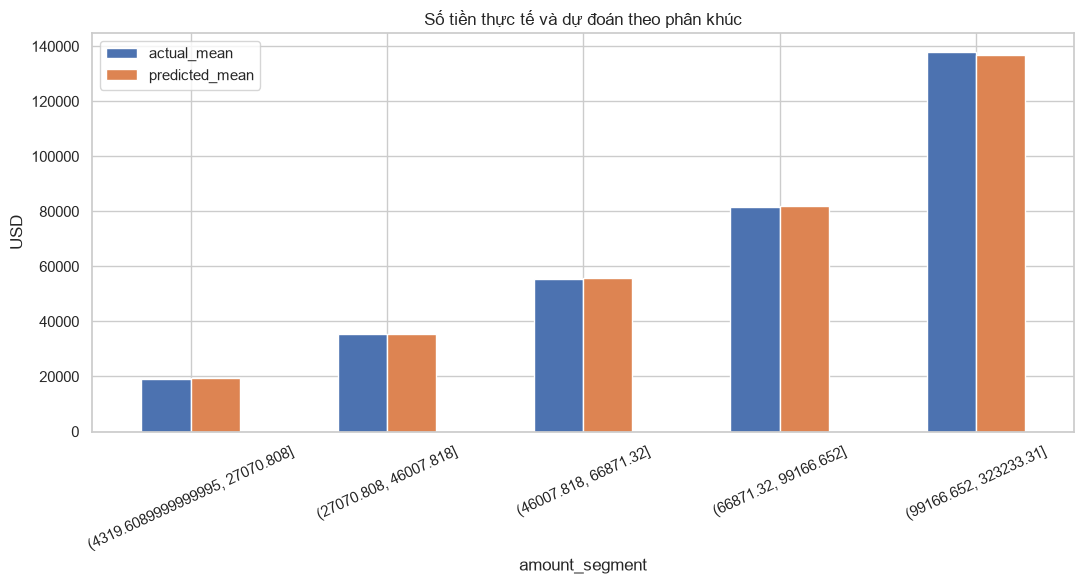

In [7]:
predictions["amount_segment"] = pd.qcut(predictions[TARGET], q=5, duplicates="drop")
segment = predictions.groupby("amount_segment", observed=True).agg(
    n=(TARGET, "size"),
    actual_mean=(TARGET, "mean"),
    predicted_mean=("prediction", "mean"),
    mae=("absolute_error", "mean"),
    bias=("residual", "mean"),
    manual_review_rate=("manual_review", "mean"),
)
display(segment)

fig, ax = plt.subplots(figsize=(11, 6))
segment[["actual_mean", "predicted_mean"]].plot.bar(ax=ax)
ax.set_title("Số tiền thực tế và dự đoán theo phân khúc")
ax.set_ylabel("USD")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 5. Kịch bản hồ sơ

In [8]:
scenario_cols = [REQUEST, "Income (USD)", "Credit Score", "Property Price", "Current Loan Expenses (USD)", TARGET, "prediction", "lower_90", "upper_90"]
scenarios = pd.concat([
    predictions.nsmallest(1, TARGET),
    predictions.iloc[[(predictions[TARGET] - predictions[TARGET].median()).abs().argmin()]],
    predictions.nlargest(1, TARGET),
    predictions.nlargest(1, "absolute_error"),
])
scenarios.index = ["Khoản nhỏ", "Khoản trung vị", "Khoản lớn", "Sai số lớn nhất"]
display(scenarios[scenario_cols])

,Loan Amount Request (USD),Income (USD),Credit Score,Property Price,Current Loan Expenses (USD),Loan Sanction Amount (USD),prediction,lower_90,upper_90
Khoản nhỏ,"6,645.560","1,220.470",741.930,"10,937.760",67.410,"4,319.610","4,714.977",0.000,"6,645.560"
Khoản trung vị,"84,974.900","2,787.900",NaN,"137,278.050",381.230,"55,233.680","62,626.392","55,683.107","69,569.677"
Khoản lớn,"380,274.480","4,748.090",870.370,"666,929.000",966.870,"323,233.310","277,079.574","270,136.289","284,022.859"
Sai số lớn nhất,"260,138.310","3,888.830",855.300,"286,414.730",856.280,"260,138.310","198,973.272","192,029.987","205,916.557"


## 6. Xuất báo cáo vận hành và kết luận

In [9]:
report_dir = ROOT / "outputs" / "reports"
review_cols = [
    "Customer ID", REQUEST, TARGET, "prediction", "lower_90", "upper_90",
    "absolute_error", "Credit Score", "Income (USD)", "Property Price",
]
predictions.loc[predictions["manual_review"], review_cols].sort_values("absolute_error", ascending=False).to_csv(
    report_dir / "manual_review_holdout.csv", index=False
)

mae_gain = 1 - metrics["mae"] / rule70_metrics["mae"]
display(Markdown(f"""
### Kết luận business

1. LendScope đạt MAE **{metrics['mae']:,.0f} USD** và cải thiện **{mae_gain:.1%}** so với quy tắc 70% trên holdout.
2. **{metrics['within_20pct']:.1%}** dự đoán nằm trong ±20% so với số tiền lịch sử. Những hồ sơ ngoài vùng này cần review thay vì tự động áp dụng.
3. Mô hình tái tạo chính sách sanction lịch sử; nó không có nhãn default sau giải ngân nên không thể tuyên bố mức tiền là an toàn về rủi ro tín dụng.
4. Khoảng bất định đơn giản đạt coverage quan sát **{coverage:.1%}** sau khi cap. Đây là công cụ triage, chưa phải conformal guarantee chính thức.
5. Production phải luôn cap theo số tiền yêu cầu, policy tài sản và gắn cờ dữ liệu ngoài miền training.
6. Dataset có provenance hạn chế; kết quả phù hợp học tập và portfolio, không dùng để ra quyết định tín dụng thật.
"""))


### Kết luận business

1. LendScope đạt MAE **3,136 USD** và cải thiện **19.7%** so với quy tắc 70% trên holdout.
2. **99.8%** dự đoán nằm trong ±20% so với số tiền lịch sử. Những hồ sơ ngoài vùng này cần review thay vì tự động áp dụng.
3. Mô hình tái tạo chính sách sanction lịch sử; nó không có nhãn default sau giải ngân nên không thể tuyên bố mức tiền là an toàn về rủi ro tín dụng.
4. Khoảng bất định đơn giản đạt coverage quan sát **89.6%** sau khi cap. Đây là công cụ triage, chưa phải conformal guarantee chính thức.
5. Production phải luôn cap theo số tiền yêu cầu, policy tài sản và gắn cờ dữ liệu ngoài miền training.
6. Dataset có provenance hạn chế; kết quả phù hợp học tập và portfolio, không dùng để ra quyết định tín dụng thật.
